<a href="https://colab.research.google.com/github/Riy666329/Bank-Customer_churn-Prediction/blob/main/Bank_Churn_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE


In [ ]:
df = pd.read_csv('BankCustomerChurnPrediction.csv')

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


In [ ]:
print(df.describe())

        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.000000   
mean   1.569094e+07    650.528800     38.921800      5.012800   76485.889288   
std    7.193619e+04     96.653299     10.487806      2.892174   62397.405202   
min    1.556570e+07    350.000000     18.000000      0.000000       0.000000   
25%    1.562853e+07    584.000000     32.000000      3.000000       0.000000   
50%    1.569074e+07    652.000000     37.000000      5.000000   97198.540000   
75%    1.575323e+07    718.000000     44.000000      7.000000  127644.240000   
max    1.581569e+07    850.000000     92.000000     10.000000  250898.090000   

       products_number  credit_card  active_member  estimated_salary  \
count     10000.000000  10000.00000   10000.000000      10000.000000   
mean          1.530200      0.70550       0.515100     100090.239881   
std           0.581654      0.45584       0.499797      57510.4

In [ ]:
print(df.isnull().sum())

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [ ]:
sns.set(style="whitegrid")

/tmp/ipykernel_23844/3081457419.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='viridis')


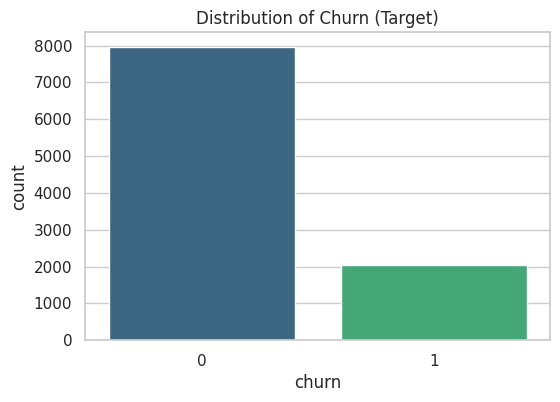

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribution of Churn (Target)')
plt.show()

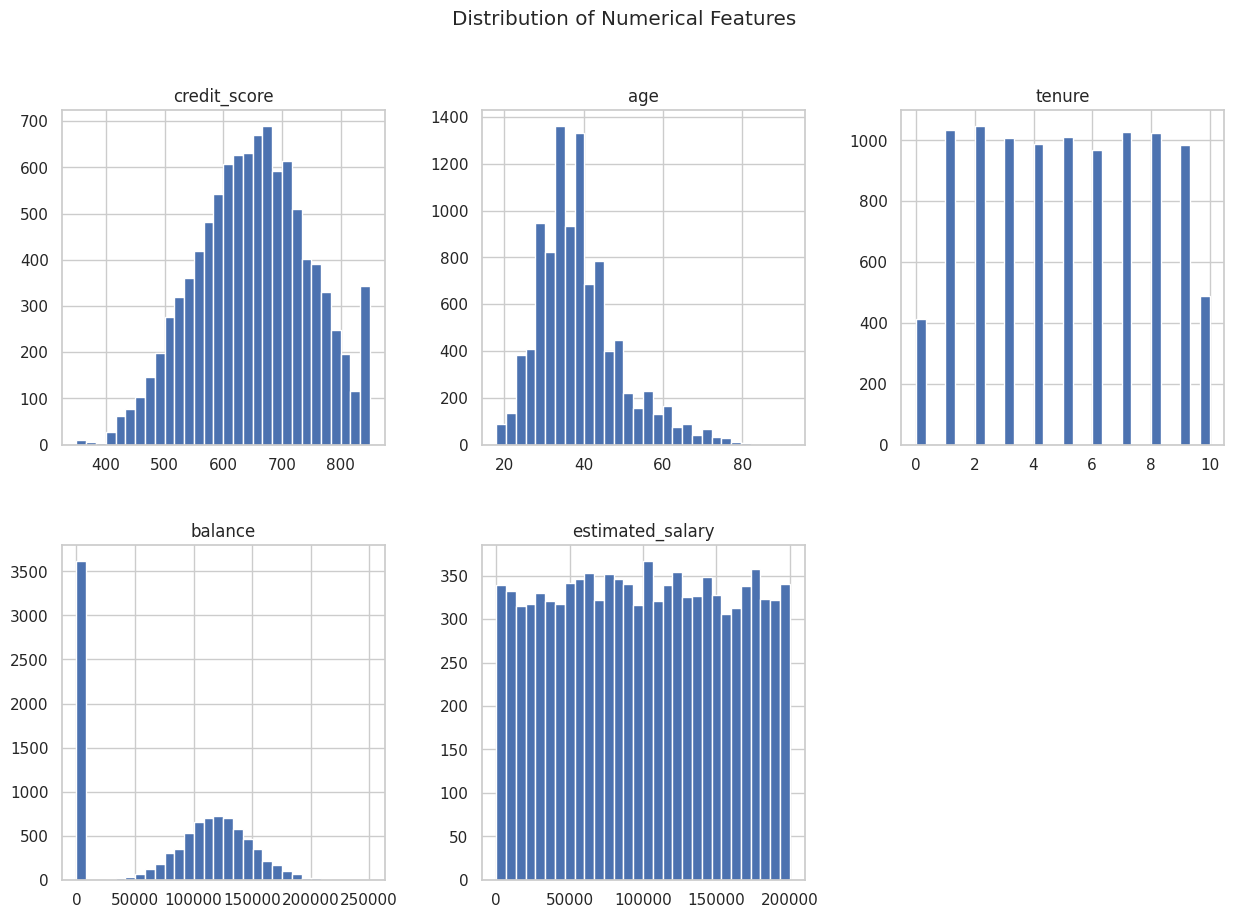

In [ ]:
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
df[num_cols].hist(bins=30, figsize=(15, 10), layout=(2, 3))
plt.suptitle('Distribution of Numerical Features')
plt.show()

/tmp/ipykernel_23844/2512150132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='churn', data=df, ax=axes[i], palette='magma')
/tmp/ipykernel_23844/2512150132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='churn', data=df, ax=axes[i], palette='magma')
/tmp/ipykernel_23844/2512150132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='churn', data=df, ax=axes[i], palette='magma')
/tmp/ipykernel_23844/2512150132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

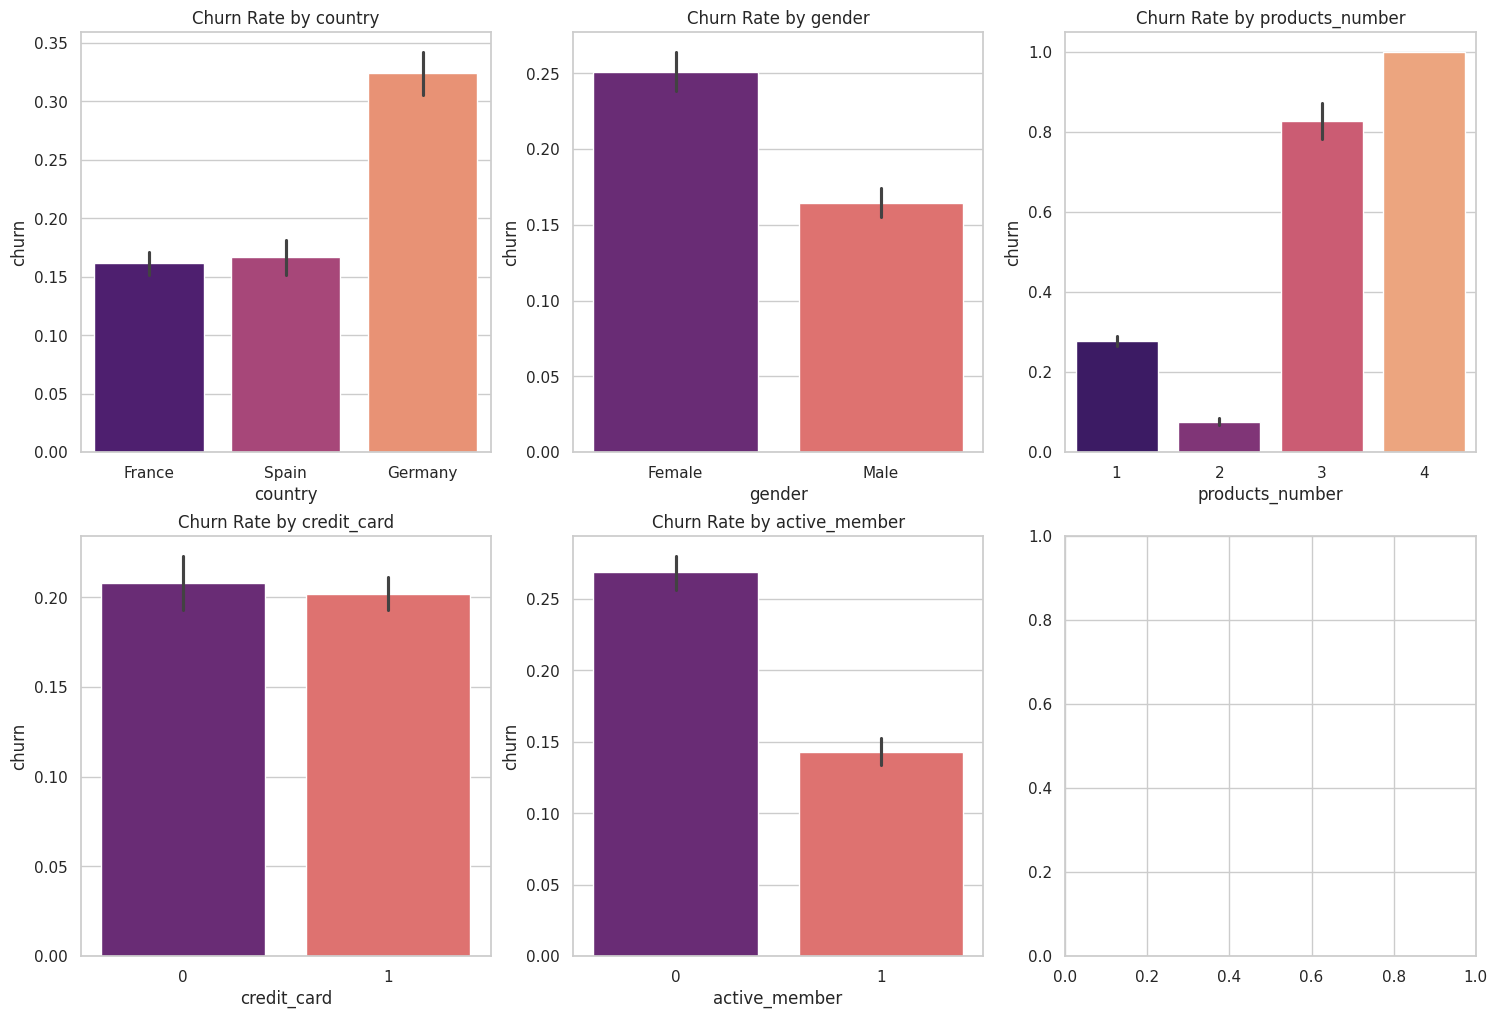

In [ ]:
cat_cols = ['country', 'gender', 'products_number', 'credit_card', 'active_member']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.barplot(x=col, y='churn', data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'Churn Rate by {col}')

In [ ]:
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

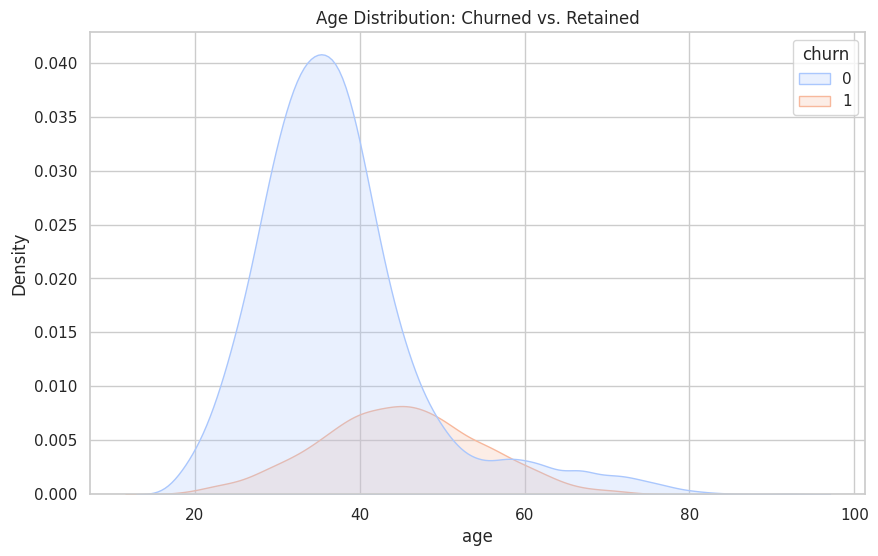

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='age', hue='churn', fill=True, palette='coolwarm')
plt.title('Age Distribution: Churned vs. Retained')
plt.show()

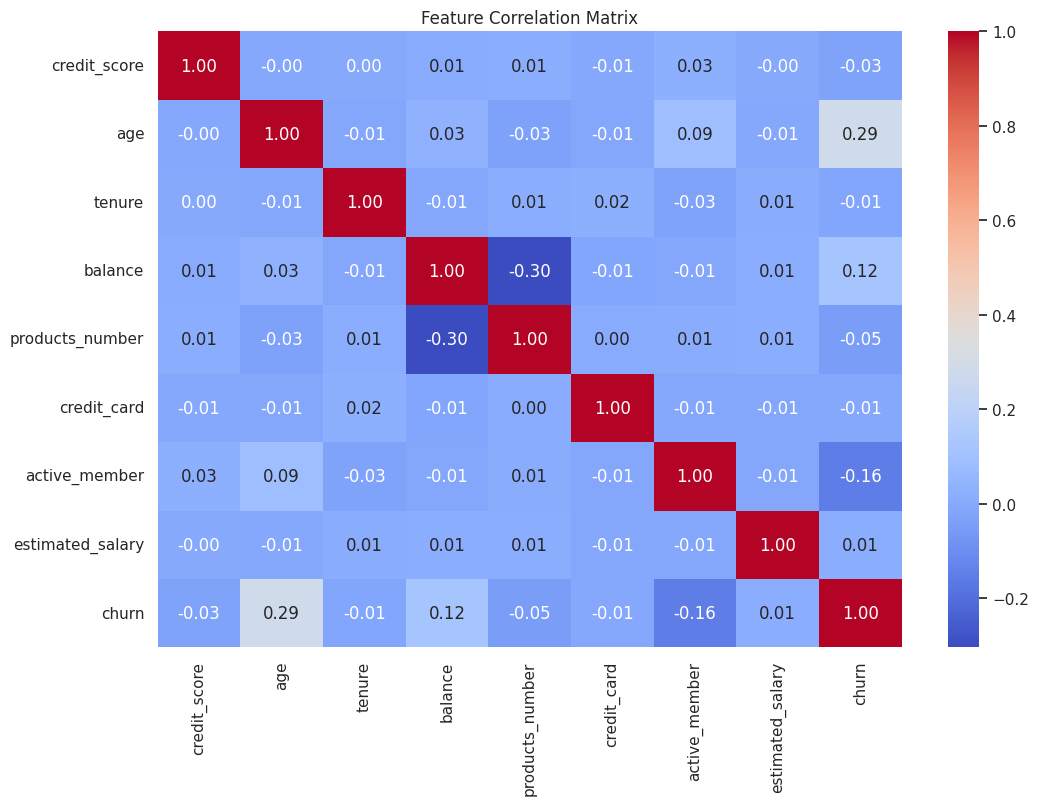

In [ ]:
plt.figure(figsize=(12, 8))
corr = df.drop(columns=['customer_id', 'country', 'gender']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
print("\n--- Churn Rate by Country ---")
print(df.groupby('country')['churn'].mean())

print("\n--- Churn Rate by Gender ---")
print(df.groupby('gender')['churn'].mean())


--- Churn Rate by Country ---
country
France     0.161548
Germany    0.324432
Spain      0.166734
Name: churn, dtype: float64

--- Churn Rate by Gender ---
gender
Female    0.250715
Male      0.164559
Name: churn, dtype: float64


In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
from sklearn.model_selection import train_test_split

x = df[['credit_score','age',	'tenure' ,'balance','products_number','credit_card','active_member','estimated_salary']]
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=42)

In [ ]:
df['churn'].unique()

array([1, 0])

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_2 = DecisionTreeClassifier()
model_2.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
pd.get_dummies(df)

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,0.00,2,1,0,96270.64,0,True,False,False,False,True
9996,15569892,516,35,10,57369.61,1,1,1,101699.77,0,True,False,False,False,True
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,True,False,False,True,False
9998,15682355,772,42,3,75075.31,2,1,0,92888.52,1,False,True,False,False,True


In [ ]:
X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']

In [ ]:
X = df.drop(['customer_id', 'churn'], axis=1)
X = pd.get_dummies(X, columns=['country', 'gender'], drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 86.40%

Detailed Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns)
print("\nTop 5 Most Important Features:\n", importances.sort_values(ascending=False).head(5))


Top 5 Most Important Features:
 age                 0.236485
estimated_salary    0.147016
credit_score        0.142756
balance             0.141756
products_number     0.130410
dtype: float64


In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [ ]:
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


In [ ]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_res_scaled, y_train_res)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:28:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"XGBoost + SMOTE Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:\n", class_report)


XGBoost + SMOTE Accuracy: 0.8540
ROC-AUC Score: 0.8676

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.91      1593
           1       0.65      0.62      0.63       407

    accuracy                           0.85      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



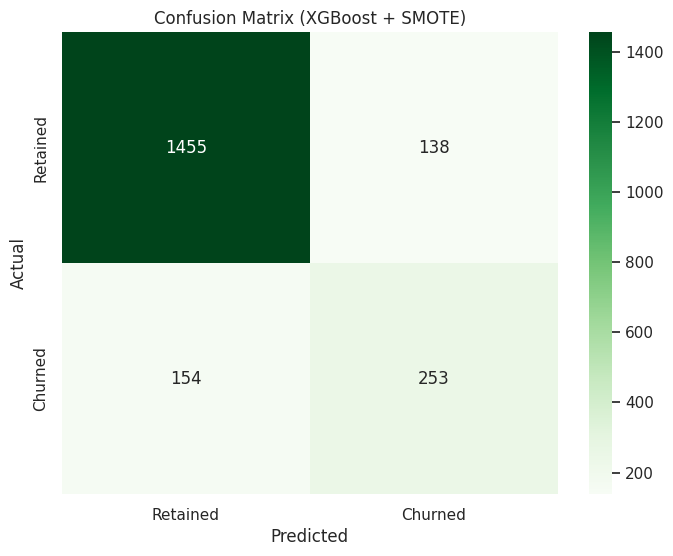

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (XGBoost + SMOTE)')
plt.savefig('xgb_smote_confusion_matrix.png')


/tmp/ipykernel_23844/1454311662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


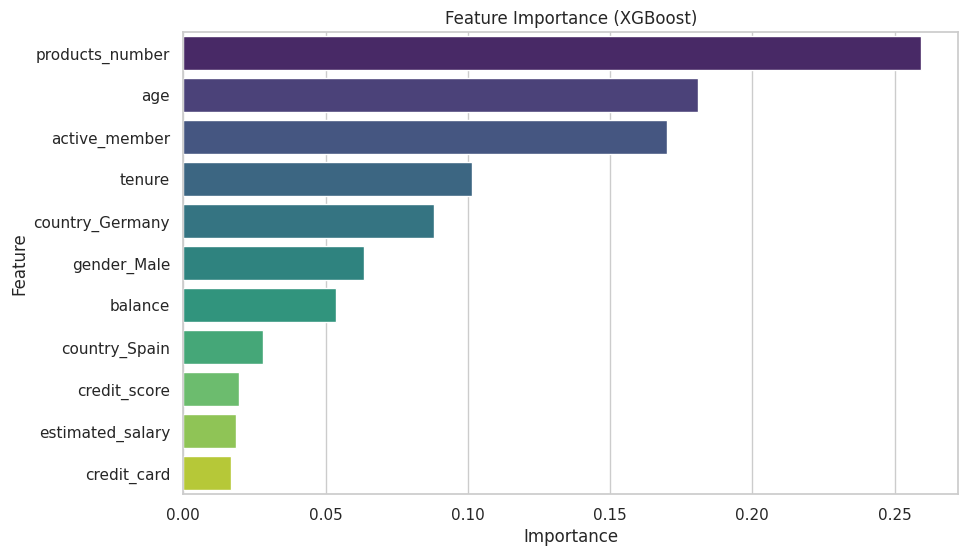

In [ ]:
importances = xgb_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance (XGBoost)')
plt.savefig('xgb_feature_importance.png')


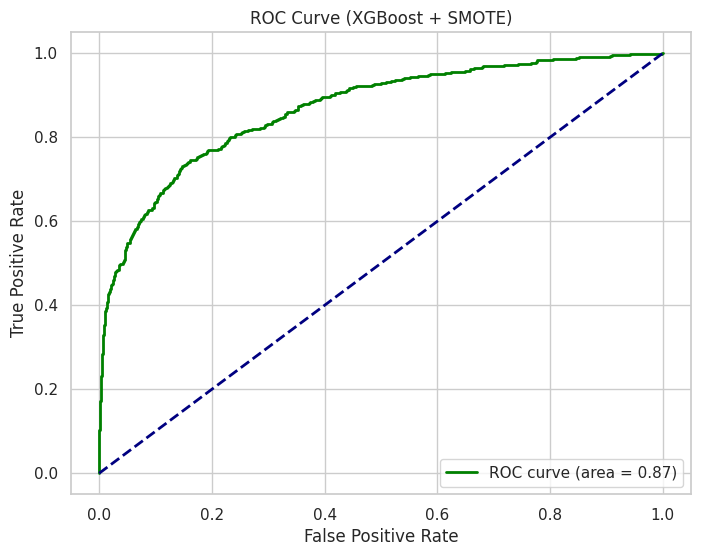

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (XGBoost + SMOTE)')
plt.legend(loc="lower right")
plt.savefig('xgb_roc_curve.png')


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
ann = Sequential([Dense(units=32, activation='relu', input_shape=(11,)),Dropout(0.2),Dense(units=16, activation='relu'),Dense(units=1, activation='sigmoid')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train_res_scaled, y_train_res, epochs=50, batch_size=32)

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6981 - loss: 0.5824
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7493 - loss: 0.5127
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7679 - loss: 0.4851
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7702 - loss: 0.4713
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7801 - loss: 0.4621
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7827 - loss: 0.4578
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7866 - loss: 0.4519
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7837 - loss: 0.4480
Epoch 9/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7849 - loss: 0.4472
Epoch 10/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7902 - loss: 0.4409
Epoch 11/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7932 - loss: 0.4424
Epoch 12/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [ ]:
loss, accuracy = ann.evaluate(X_test_scaled, y_test)
print(f"ANN Accuracy: {accuracy:.2%}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7990 - loss: 0.4300
ANN Accuracy: 79.90%


In [ ]:
from tensorflow.keras.layers import Conv1D, Flatten, MaxPooling1D

In [ ]:
X_train_cnn = X_train_res_scaled.reshape(X_train_res_scaled.shape[0], X_train_res_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

In [ ]:
cnn = Sequential([Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(11, 1)),
    MaxPooling1D(pool_size=2),Flatten(),
    Dense(units=16, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.fit(X_train_cnn, y_train_res, epochs=50, batch_size=32)

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6956 - loss: 0.5850
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7388 - loss: 0.5311
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7673 - loss: 0.4930
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7759 - loss: 0.4737
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7827 - loss: 0.4609
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7839 - loss: 0.4560
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7912 - loss: 0.4476
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7911 - loss: 0.4448
Epoch 9/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7938 - loss: 0.4429
Epoch 10/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7960 - loss: 0.4385
Epoch 11/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7937 - loss: 0.4366
Epoch 12/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [ ]:
loss, accuracy = cnn.evaluate(X_test_cnn, y_test)
print(f"CNN Accuracy: {accuracy:.2%}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8240 - loss: 0.4059
CNN Accuracy: 82.40%
